In [2]:
# # Install all project dependencies in one go
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
# !pip install datasets transformers
# !pip install opencv-python numpy scipy pillow matplotlib
# !pip install aiohttp fsspec

# print("\n" + "="*30)
# print("✅ ALL LIBRARIES INSTALLED SUCCESSFULLY!")
# print("="*30)

In [3]:
# input: parquet files
# process: load a portion of dataset, create 6 channel tensor input, apply data augmentation(later), train model, get accuracy , predict
# output: model ready to predict

In [3]:
# EDA

In [3]:
# 1. The Setup & Loading
# This cell loads the dataset and sets up the basic mapping based on the dataset metadata:

# Label 0: AI-generated
# Label 1: Real (human-captured)

from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# Load dataset with the verification bypass we discussed
print("Loading dataset...")
ds = load_dataset("Parveshiiii/AI-vs-Real", verification_mode="no_checks")

# Define the label mapping
label_names = {0: "AI-Generated", 1: "Real"}

print(f"\nDataset Structure:\n{ds}")

C:\Users\LENOVO\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset...



Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['image', 'binary_label'],
        num_rows: 13999
    })
})


In [4]:
# 2. Class Balance & Metadata Analysis
# Convert the metadata (without the heavy images) to a DataFrame
# Note: Using 'binary_label' based on previous output

import pandas as pd
df = pd.DataFrame(ds['train'].remove_columns("image"))

print("--- Dataset Statistics ---")
print(f"Total Examples: {len(df)}")

# Calculate the distribution
distribution = df['binary_label'].value_counts()
print("\nClass Distribution:")
print(distribution)

# Calculate percentages
print("\nPercentage Distribution:")
print(distribution / len(df) * 100)

--- Dataset Statistics ---
Total Examples: 13999

Class Distribution:
binary_label
1    10666
0     3333
Name: count, dtype: int64

Percentage Distribution:
binary_label
1    76.191157
0    23.808843
Name: count, dtype: float64


In [6]:
# dataset is significantly imbalanced.
# Class 1 (Real): ~76%
# Class 0 (AI): ~24%
# Why this matters for the pipeline: If we train the model as-is, 
# it might learn to just guess "Real" every time to get a 76% accuracy without
# actually learning any features. When we move to the training stage, we will 
# need to use class weights or oversampling to make sure the model pays extra 
# attention to the AI-generated samples.

In [ ]:
# Stage 1.3: Visual & Resolution Check
# This step visually checks the dataset images and their sizes before training.

import matplotlib.pyplot as plt

# 1. Filter a few of each to see them
ai_samples = ds['train'].filter(lambda x: x['binary_label'] == 0).select(range(3))
real_samples = ds['train'].filter(lambda x: x['binary_label'] == 1).select(range(3))

# 2. Display them
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(3):
    # AI row
    axes[0, i].imshow(ai_samples[i]['image'])
    axes[0, i].set_title(f"AI (Label 0)\nSize: {ai_samples[i]['image'].size}")
    axes[0, i].axis('off')
    
    # Real row
    axes[1, i].imshow(real_samples[i]['image'])
    axes[1, i].set_title(f"Real (Label 1)\nSize: {real_samples[i]['image'].size}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# 3. Check for consistency in a larger sample
print("Checking dimensions for a larger sample...")
sizes = [ds['train'][i]['image'].size for i in range(100)]
print(f"Unique sizes found in first 100 images: {set(sizes)}")

Filter:   0%|          | 0/13999 [00:00<?, ? examples/s]

Filter:  71%|███████▏  | 10000/13999 [02:32<01:59, 33.47 examples/s]

In [ ]:
# the results tell us:Non-Uniform Sizes: Your unique sizes are all over the place (e.g., 320x240, 640x361, 600x400). 
#     A Neural Network requires a fixed input shape (like a square $224 \times 224$ matrix) because the mathematical
# weights in the layers are fixed.Varying Aspect Ratios: Some images are wide (landscape), and some are tall (portrait).
#     If we just "squish" them to a square, we might distort the very textures the AI needs to look at to detect "fake" pixels.
#     High Resolution: Most are around 640 pixels. This is good quality, but processing $640 \times 640$ with 6 channels on your
# Ryzen 5 laptop might be slow. Resizing will be our friend here.

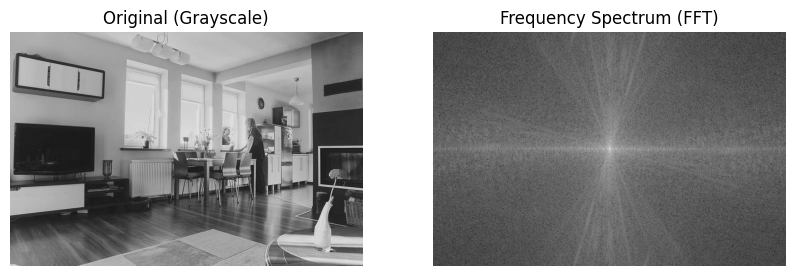

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Take one image from dataset and convert it to grayscale
sample_img = ds['train'][0]['image'].convert('L')

# Convert image into NumPy matrix
img_np = np.array(sample_img)

# -----------------------------------------------------------
# STEP 3: Apply 2D Fast Fourier Transform (FFT)
# -----------------------------------------------------------
# FFT converts the image from:
#
# Spatial Domain  -> normal pixel representation
# to
# Frequency Domain -> representation based on pixel changes
#
# Low frequencies:
# smooth regions / gradual intensity changes
#
# High frequencies:
# edges, textures, noise, sharp transitions

f_transform = np.fft.fft2(img_np)

# Shift low frequencies to the center for better visualization
f_shift = np.fft.fftshift(f_transform)

# Compute magnitude spectrum using log scale
magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)

# Plot original grayscale image
plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(img_np, cmap='gray')
plt.title('Original (Grayscale)')
plt.axis('off')

# Plot FFT frequency spectrum
plt.subplot(122)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Frequency Spectrum (FFT)')
plt.axis('off')

# Display both images
plt.show()

In [ ]:
# Step 2.1: Creating and Splitting the Balanced Dataset (Preparing the dataset)

In [ ]:
import random
from datasets import DatasetDict

# Get indices of all AI-generated images (label = 0)
ai_indices = [i for i, label in enumerate(ds['train']['binary_label']) if label == 0]

# Get indices of all real images (label = 1)
real_indices = [i for i, label in enumerate(ds['train']['binary_label']) if label == 1]

# Number of samples to take from each class
subset_size = 3000

# Set random seed for reproducibility
random.seed(42)

# Randomly select 3000 AI image indices
selected_ai = random.sample(ai_indices, subset_size)

# Randomly select 3000 Real image indices
selected_real = random.sample(real_indices, subset_size)

# Combine both classes into one balanced list
balanced_indices = selected_ai + selected_real

# Shuffle indices to mix AI and Real samples randomly
random.shuffle(balanced_indices)

# Create balanced dataset using selected indices
balanced_ds = ds['train'].select(balanced_indices)

# Split dataset into 80% training and 20% validation/testing
final_split = balanced_ds.train_test_split(test_size=0.2, seed=42)

# Print final dataset information
print("--- Dataset Balanced and Split Complete ---")
print(f"Final Structure: {final_split}")
print(f"Training rows: {len(final_split['train'])}")
print(f"Validation rows: {len(final_split['test'])}")

--- Dataset Balanced and Split Complete ---
Final Structure: DatasetDict({
    train: Dataset({
        features: ['image', 'binary_label'],
        num_rows: 4800
    })
    test: Dataset({
        features: ['image', 'binary_label'],
        num_rows: 1200
    })
})
Training rows: 4800
Validation rows: 1200


In [13]:
# Check the first 10 labels of the training split
print(final_split['train']['binary_label'][:100])

[0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1]


In [ ]:
# This class helps the model get one image and its label from the dataset during training.

import torch
from torch.utils.data import Dataset
import numpy as np

class AIvsRealDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        """
        hf_dataset: This will be your final_split['train'] or final_split['test']
        transform: Your 6-channel and augmentation logic
        """
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        # 1. Get the PIL image and label from the HF object
        item = self.dataset[index]
        image = item['image']  # Already a PIL image
        label = item['binary_label']
        
        # 2. Apply your custom 6-channel transform
        if self.transform:
            # This is where we will call your FFT modules later
            image = self.transform(image)
        
        # 3. Convert label to tensor
        label = torch.tensor(label, dtype=torch.long)
            
        return image, label

In [ ]:
# Stage 2.2: The Optimized 6-Channel Transformer

In [ ]:
# This code extracts RGB, FFT, Noise Residual, and ELA features from an image and combines them into a 6-channel tensor. The generated tensor is used as input for the deep learning model.

import io
from PIL import Image
import torch
import numpy as np
import cv2
from scipy.fftpack import fft2, fftshift

class MultiSignalTransform:
    def __init__(self, target_size=(224, 224)):
        self.target_size = target_size

    def __call__(self, pil_img):
        # 1. Convert PIL to OpenCV (BGR) and Resize
        img_bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
        img = cv2.resize(img_bgr, self.target_size)
        
        # --- SIGNAL 1: RGB (3 Channels) ---
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        rgb_channels = img_rgb.astype(np.float32) / 255.0
        rgb_stack = np.transpose(rgb_channels, (2, 0, 1)) # (3, 224, 224)

        # --- SIGNAL 2: FFT (1 Channel) ---
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        f_transform = fft2(gray)
        f_shift = fftshift(f_transform)
        magnitude_spectrum = np.log(np.abs(f_shift) + 1)
        fft_channel = cv2.normalize(magnitude_spectrum, None, 0, 1, cv2.NORM_MINMAX)

        # --- SIGNAL 3: Noise Residue (1 Channel) ---
        denoised = cv2.medianBlur(gray, 3)
        noise_residue = cv2.absdiff(gray, denoised)
        noise_channel = cv2.normalize(noise_residue, None, 0, 1, cv2.NORM_MINMAX)

        # --- SIGNAL 4: ELA (1 Channel) ---
        # IN-MEMORY ELA (Avoids slow disk I/O)
        is_success, buffer = cv2.imencode(".jpg", img, [cv2.IMWRITE_JPEG_QUALITY, 90])
        img_low = cv2.imdecode(buffer, 1)
        ela_diff = cv2.absdiff(img, img_low)
        ela_gray = cv2.cvtColor(ela_diff, cv2.COLOR_BGR2GRAY)
        ela_channel = cv2.normalize(ela_gray, None, 0, 1, cv2.NORM_MINMAX)

        # 2. Stack into (6, 224, 224)
        fusion_tensor = np.concatenate([
            rgb_stack, 
            fft_channel[np.newaxis, ...], 
            noise_channel[np.newaxis, ...], 
            ela_channel[np.newaxis, ...]
        ], axis=0)
        
        return torch.from_numpy(fusion_tensor).float()

In [ ]:
# This code creates training/testing datasets where every image is automatically converted into a 6-channel forensic tensor before being sent to the model.


# 1. Initialize our custom transformer
my_transform = MultiSignalTransform(target_size=(224, 224))

# 2. Create the PyTorch Training and Validation Datasets
# Note: final_split was the shuffled 6000-image dataset we made earlier
train_dataset = AIvsRealDataset(final_split['train'], transform=my_transform)
val_dataset = AIvsRealDataset(final_split['test'], transform=my_transform)

# 3. Test it!
sample_tensor, sample_label = train_dataset[0]
print(f"Sample Tensor Shape: {sample_tensor.shape}") # Should be torch.Size([6, 224, 224])
print(f"Label: {sample_label} ({'Real' if sample_label == 1 else 'AI'})")

Sample Tensor Shape: torch.Size([6, 224, 224])
Label: 0 (AI)


In [ ]:
# prepare model

In [ ]:
# This code modifies pretrained ResNet50 so it can accept 6-channel forensic tensors and perform binary classification between AI-generated and real images.


import torch
import torch.nn as nn
from torchvision import models

# 1. Load the pretrained ResNet-50 backbone
# This model has been trained on millions of images already
device = torch.device("cpu") # Optimized for your Ryzen 5
# device = torch.device("cuda") # for lab computer with GPU
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 2. INPUT SURGERY: Modify the very first layer (conv1)
# Original expects 3 channels (RGB); we change it to 6
original_conv = model.conv1

model.conv1 = nn.Conv2d(
    in_channels=6, 
    out_channels=original_conv.out_channels, 
    kernel_size=original_conv.kernel_size, 
    stride=original_conv.stride, 
    padding=original_conv.padding, 
    bias=False
)

# 3. WEIGHT WARM-START
# We copy the learned RGB weights into the 3 new channels (FFT, Noise, ELA)
# This gives the model a massive head start in learning
with torch.no_grad():
    model.conv1.weight[:, :3, :, :] = original_conv.weight
    model.conv1.weight[:, 3:, :, :] = original_conv.weight 

# 4. OUTPUT SURGERY: Modify the final layer (fc)
# ResNet usually looks for 1000 classes; we only need 1 (Binary)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1) 

# Move model to your CPU
model = model.to(device)

print("--- Surgery Successful ---")
print(f"New Input Layer: {model.conv1}")
print(f"New Output Layer: {model.fc}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\LENOVO/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:20<00:00, 4.92MB/s]


--- Surgery Successful ---
New Input Layer: Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
New Output Layer: Linear(in_features=2048, out_features=1, bias=True)


In [ ]:
# Stage 3.2: The Dry Run (Verification)

In [ ]:
# This code performs a dry run by passing one 6-channel image tensor through the model to check whether the model generates predictions correctly. It outputs the prediction probability and compares it with the actual label.




# 1. Grab a single 6-channel sample
# sample_tensor will be shape (6, 224, 224)
sample_tensor, sample_label = train_dataset[0]

# 2. Add the Batch Dimension: (6, 224, 224) -> (1, 6, 224, 224)
# PyTorch models always expect (Batch, Channels, Height, Width)
test_input = sample_tensor.unsqueeze(0).to(device)

# 3. Pass through the model in evaluation mode
model.eval() 
with torch.no_grad():
    raw_output = model(test_input)
    # Apply sigmoid to see the probability (0 to 1)
    probability = torch.sigmoid(raw_output).item()

print("--- Dry Run Results ---")
print(f"Input Shape: {test_input.shape}")
print(f"Model Raw Output (Logit): {raw_output.item():.4f}")
print(f"Predicted Probability of being 'Real': {probability:.4f}")
print(f"Actual Label: {sample_label} ({'Real' if sample_label == 1 else 'AI'})")

--- Dry Run Results ---
Input Shape: torch.Size([1, 6, 224, 224])
Model Raw Output (Logit): -0.0574
Predicted Probability of being 'Real': 0.4857
Actual Label: 0 (AI)


In [ ]:
# Stage 4: DataLoaders

In [ ]:
# This code creates DataLoader to divide the training and validation datasets into small batches(16) so the model can process images efficiently during training.

# 4800 / 16 = 300 batches

# 1200/ 16 = 17 batches

from torch.utils.data import DataLoader

# 1. Create the Training Loader (Shuffled)
train_loader = DataLoader(
    train_dataset, 
    batch_size=16, 
    shuffle=True, 
    num_workers=0 # Setting to 0 is safer for Windows to avoid 'multiprocessing' errors
)

# 2. Create the Validation Loader (No need to shuffle)
val_loader = DataLoader(
    val_dataset, 
    batch_size=16, 
    shuffle=False, 
    num_workers=0
)

print(f"DataLoaders Ready!")
print(f"Training Batches: {len(train_loader)}")
print(f"Validation Batches: {len(val_loader)}")

DataLoaders Ready!
Training Batches: 300
Validation Batches: 75


In [ ]:
# This function performs one complete training step: prediction, loss calculation, backpropagation, and weight update.

 # Create training loop:
# ● forward pass
# ● loss calculation
# ● backward pass
import torch
import torch.nn as nn
import torch.optim as optim

def train_one_step(model, optimizer, criterion, inputs, labels):
    # A. Put model in training mode (enables Dropout/BatchNorm)
    model.train()

    # B. Zero the Gradients
    # Crucial: PyTorch accumulates gradients by default. 
    # We must clear them before every new step!
    optimizer.zero_grad()

    # C. Forward Pass
    # Passing the 6-channel input (from Level 5) through the model
    outputs = model(inputs) 
    
    # D. Calculate Loss
    # Labels usually need to be the same shape as outputs for BCE
    loss = criterion(outputs, labels.float().view_as(outputs))

    # E. Backward Pass (Backpropagation)
    # This calculates the gradients (derivatives) for every parameter
    loss.backward()

    # F. Optimizer Step (Weight Update)
    # This actually changes the weights of the model
    optimizer.step()

    return loss.item()

In [ ]:
# Trains the ResNet50 model using training batches,
# using forward pass, loss calculation, backpropagation, and Adam optimization.
# After each epoch, the model is evaluated on validation data to measure accuracy.

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Setup Criterion and Optimizer
# Using BCEWithLogitsLoss because your model outputs raw logits (no Sigmoid at the end)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001) # Lower LR for fine-tuning ResNet

# 2. Complete Epoch Loop
def run_training(num_epochs=3):
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for i, (inputs, labels) in enumerate(train_loader):
            # Use your train_one_step logic here
            loss_val = train_one_step(model, optimizer, criterion, inputs, labels)
            epoch_loss += loss_val
            
            if (i + 1) % 50 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/300], Loss: {loss_val:.4f}")

        # 3. Validation Step (Checking Accuracy after every epoch)
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                # Predictions: anything > 0 is Real (1), < 0 is AI (0)
                predictions = (outputs > 0).float()
                total += labels.size(0)
                correct += (predictions.view_as(labels) == labels).sum().item()
         
        accuracy = 100 * correct / total
        print(f"--- Epoch {epoch+1} Summary: Avg Loss: {epoch_loss/300:.4f}, Accuracy: {accuracy:.2f}% ---")

# Execute
# run_training(num_epochs=3)

In [ ]:
# This code trains the model, evaluates validation accuracy after every epoch, and automatically saves the best-performing model as a .pth file.


import os

# 1. Create a directory for your models
os.makedirs("models", exist_ok=True)

# 1. Setup Criterion and Optimizer
# Using BCEWithLogitsLoss because your model outputs raw logits (no Sigmoid at the end)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001) # Lower LR for fine-tuning ResNet

def train_with_saving(num_epochs=3):
    best_accuracy = 0.0
    model_path = "models/ai_vs_real_resnet50.pth"
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for i, (inputs, labels) in enumerate(train_loader):
            loss_val = train_one_step(model, optimizer, criterion, inputs, labels)
            epoch_loss += loss_val
            
            if (i + 1) % 50 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/300], Loss: {loss_val:.4f}")

        # 2. Validation Phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                predictions = (outputs > 0).float()
                total += labels.size(0)
                correct += (predictions.view_as(labels) == labels).sum().item()
        
        current_acc = 100 * correct / total
        print(f"--- Epoch {epoch+1} Summary: Avg Loss: {epoch_loss/300:.4f}, Accuracy: {current_acc:.2f}% ---")

        # 3. Save the Best Model
        if current_acc > best_accuracy:
            best_accuracy = current_acc
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'accuracy': best_accuracy,
            }, model_path)
            print(f"⭐ New Best Model Saved with {best_accuracy:.2f}% Accuracy!")

    print(f"\nTraining Complete. Best Accuracy: {best_accuracy:.2f}%")
    print(f"Model saved at: {os.path.abspath(model_path)}")

# To start training, run:
train_with_saving(num_epochs=3)

Epoch [1/3], Batch [50/300], Loss: 0.1534
Epoch [1/3], Batch [100/300], Loss: 0.4939
Epoch [1/3], Batch [150/300], Loss: 0.2686
Epoch [1/3], Batch [200/300], Loss: 0.0185
Epoch [1/3], Batch [250/300], Loss: 0.0239
Epoch [1/3], Batch [300/300], Loss: 0.0685
--- Epoch 1 Summary: Avg Loss: 0.1886, Accuracy: 98.00% ---
⭐ New Best Model Saved with 98.00% Accuracy!
Epoch [2/3], Batch [50/300], Loss: 0.0609
Epoch [2/3], Batch [100/300], Loss: 0.0182
Epoch [2/3], Batch [150/300], Loss: 0.0206
Epoch [2/3], Batch [200/300], Loss: 0.1347
Epoch [2/3], Batch [250/300], Loss: 0.0280
Epoch [2/3], Batch [300/300], Loss: 0.0447
--- Epoch 2 Summary: Avg Loss: 0.0477, Accuracy: 97.42% ---
Epoch [3/3], Batch [50/300], Loss: 0.0017
Epoch [3/3], Batch [100/300], Loss: 0.0150
Epoch [3/3], Batch [150/300], Loss: 0.0030
Epoch [3/3], Batch [200/300], Loss: 0.0056
Epoch [3/3], Batch [250/300], Loss: 0.1518
Epoch [3/3], Batch [300/300], Loss: 0.0176
--- Epoch 3 Summary: Avg Loss: 0.0202, Accuracy: 98.08% ---
⭐ Ne

In [ ]:
# Stage 7: Inference / Prediction Code

In [ ]:
# This code loads the trained model, converts a new image into a 6-channel forensic tensor, and predicts whether the image is AI-generated or real.


import torch
from PIL import Image

def predict_image(image_path, model_path="models/ai_vs_real_resnet50.pth"):
    # 1. Setup Device and Model
    device = torch.device("cpu")
    
    # We must recreate the architecture exactly as we did for training
    inference_model = models.resnet50()
    inference_model.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
    inference_model.fc = nn.Linear(inference_model.fc.in_features, 1)
    
    # 2. Load the saved weights (state_dict)S
    checkpoint = torch.load(model_path, map_location=device)
    inference_model.load_state_dict(checkpoint['model_state_dict'])
    inference_model.to(device)
    inference_model.eval() # Set to evaluation mode

    # 3. Process the Image
    # Load and apply our custom 6-channel transform
    img = Image.open(image_path)
    transform = MultiSignalTransform(target_size=(224, 224))
    input_tensor = transform(img).unsqueeze(0).to(device) # Add batch dimension

    # 4. Run Prediction
    with torch.no_grad():
        output = inference_model(input_tensor)
        probability = torch.sigmoid(output).item()
    
    # 5. Interpret Results
    label = "REAL" if probability > 0.5 else "AI-GENERATED"
    confidence = probability if probability > 0.5 else (1 - probability)
    
    print(f"--- Prediction Result ---")
    print(f"File: {image_path}")
    print(f"Verdict: {label}")
    print(f"Confidence: {confidence*100:.2f}%")
    
    return label, confidence

# Example Usage (Run this after training is finished):
predict_image("images/IMGAI1.webp")
predict_image("images/IMGAI2.jpg")
predict_image("images/IMGAI3.jpg")
predict_image("images/IMGAI4.jpg")
predict_image("images/IMGREAL1.jpg")
predict_image("images/IMGREAL2.jpg")
predict_image("images/IMGREAL3.jpg")
predict_image("images/IMGREAL4.jpg")
predict_image("images/IMGREAL5.jpg")

--- Prediction Result ---
File: images/IMGAI1.webp
Verdict: AI-GENERATED
Confidence: 99.23%
--- Prediction Result ---
File: images/IMGAI2.jpg
Verdict: REAL
Confidence: 99.91%
--- Prediction Result ---
File: images/IMGAI3.jpg
Verdict: REAL
Confidence: 99.77%
--- Prediction Result ---
File: images/IMGAI4.jpg
Verdict: AI-GENERATED
Confidence: 92.41%
--- Prediction Result ---
File: images/IMGREAL1.jpg
Verdict: REAL
Confidence: 91.55%
--- Prediction Result ---
File: images/IMGREAL2.jpg
Verdict: AI-GENERATED
Confidence: 99.66%
--- Prediction Result ---
File: images/IMGREAL3.jpg
Verdict: REAL
Confidence: 99.93%
--- Prediction Result ---
File: images/IMGREAL4.jpg
Verdict: REAL
Confidence: 56.41%
--- Prediction Result ---
File: images/IMGREAL5.jpg
Verdict: AI-GENERATED
Confidence: 85.72%


('AI-GENERATED', 0.8571857959032059)

In [ ]:
# # TO RESUME TRAINING:
# checkpoint = torch.load("models/ai_vs_real_resnet50.pth")
# model.load_state_dict(checkpoint['model_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# start_epoch = checkpoint['epoch']

# print(f"Resuming from Epoch {start_epoch}")
# # Then call your train function starting from start_epoch

In [27]:
import os
print(os.getcwd())

c:\Users\LENOVO\veriScanAI\veriScanAI
